# Testing Different Calibration Methods to Enhance Method
**Author:** Eliya Levin

**Contact details:** please mail questions to eliya.levin@mail.huji.ac.il

**Last update:** 28/05/2026

## Setup

### Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import time
from IPython.display import Markdown
from shapely import wkb
import glob
import sys
import importlib

### Path

In [2]:
current_dir = os.getcwd() # directory path of the notebook
main_dir = os.path.abspath(os.path.join(current_dir, "..")) # parent directory path of the notebook

In [3]:
data_path = r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\Data'

### Link function notebook

In [4]:
# Adding path to system
sys.path.append(main_dir)

In [5]:
# Importing relevant functions
from functions import get_len, get_count, post_count, get_area, post_area, get_density, wrap_api_query # API call requests
from functions import get_add_from_cum, semi_norm_mix_transform, assess_feature_completeness # Method functions
from functions import generate_measure_sample_plot # plotting functions

## Different Functions additions

In [ ]:
# Test function with saturation percentage using metric
def saturation_test(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        #-------------------------------------------------------------------------------------------------------#
        #                                               FIX
        #-------------------------------------------------------------------------------------------------------#
        gdf['percentage_until_saturation'] = gdf['normalized_cum_per'] / saturation_point['normalized_cum_per']
        #-------------------------------------------------------------------------------------------------------#
        #                                               FIX
        #-------------------------------------------------------------------------------------------------------#
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#

        #--------------------------------------------------------------------------------------------------------------------#
        #                                               FIX
        #--------------------------------------------------------------------------------------------------------------------#
            stable['abs_change'] = stable['normalized_cum_per'] / stable['normalized_cum_per'].max() # Calculate absolute change
            if (stable['abs_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['abs_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition period shorter than threshold'
                        }
        #--------------------------------------------------------------------------------------------------------------------#
        #                                               FIX
        #--------------------------------------------------------------------------------------------------------------------#
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                #-------------------------------------------------------------------------------------------------------#
                #                                               FIX
                #-------------------------------------------------------------------------------------------------------#
                gdf['percentage_until_saturation'] = gdf['normalized_cum_per'] / saturation_point['normalized_cum_per']
                #-------------------------------------------------------------------------------------------------------#
                #                                               FIX
                #-------------------------------------------------------------------------------------------------------#
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

In [ ]:
# update absolute addition - relative to first index and not maximal one
def absolute_addition(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#
            #------------------------------------------------------------------------------------------#
            #                                           FIX                                            #
            #------------------------------------------------------------------------------------------#
            stable['count_change'] = stable['count'] / stable.loc[0,'count'] # Calculate absolute change
            #------------------------------------------------------------------------------------------#
            #                                           FIX                                            #
            #------------------------------------------------------------------------------------------#
            if (stable['count_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['count_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition period shorter than threshold'
                        }
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

In [ ]:
# Assess the feature completness measure of some polygon using cumulative feature counts and lengths/areas
def assess_feature_completeness(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#

            stable['count_change'] = stable['count'] / stable['count'].max() # Calculate absolute change
            if (stable['count_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['count_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    print('Data incomplete: no stable absolute addition period')
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

## Test Normalizations

In [8]:
il_bld_counts = pd.read_csv(main_dir + r'\1) Data\3) validity\israel_chull_bld_counts.csv')
il_bld_areas = pd.read_csv(main_dir + r'\1) Data\3) validity\israel_chull_bld_areas.csv')

In [17]:
min_max = min_max_normalize(il_bld_counts, il_bld_areas)
relative_change = relative_change_normalize(il_bld_counts, il_bld_areas)

<Axes: >

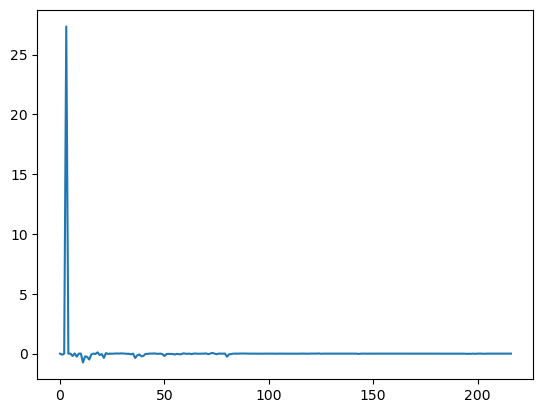

In [13]:
relative_change['relative_change_cumulative_percentage'].plot()

In [15]:
min_max.head()

,Unnamed: 0,timestamp,count,size,cumulative_percentage,minval_cumulative_percentage
0,0,2008-01-01 00:00:00+00:00,2.0,11006.41,5503.205000,0.036859
1,1,2008-02-01 00:00:00+00:00,3.0,14987.26,4995.753333,0.033267
2,2,2008-03-01 00:00:00+00:00,3.0,14987.26,4995.753333,0.033267
3,3,2008-04-01 00:00:00+00:00,4.0,566372.71,141593.177500,1.000000
4,4,2008-05-01 00:00:00+00:00,4.0,565997.56,141499.390000,0.999336


<Axes: >

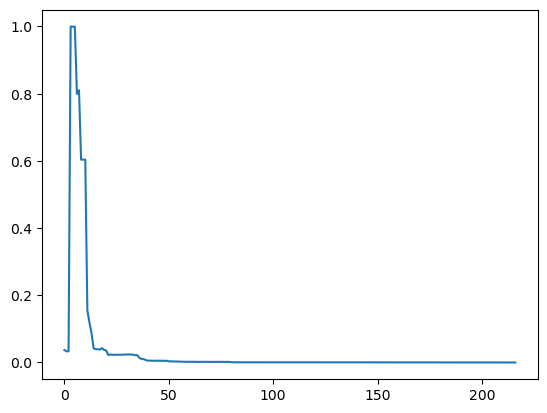

In [18]:
min_max['minmax_cumulative_percentage'].plot()

As we can see, min-max seems to keep a better classified shape. This also fits what we can learn from [Mazziotta et al. (2022)]( https://doi.org/10.1002/env.2730), where they talk about three normalizationmethods with Min-Max being the most relevant for our case. However, they do note interpretability problems (with the mean transforming and making a problematic comparability of temporal values). This concludes that our best bet is to keep the absolute maximum normalization method we used before, being backed even more by [Lima et al. (2023)](https://doi.org/10.1016/j.bdr.2023.100407) because:
* The data distribution stays the same (mean, median and variation stay close to the original structure).
* The values are scaled $[0,1]$, which allows a format classic threshold we can use.
* The values are easy to interpret - the percentage from the maximal addition of area per unit, meaning a stabilization would mean no more large additions.

We can think of incorporating also a relative change test to validate positively perhaps a mild change that indicates saturation, or the rate of change (slope?).
Furthermore, we can try to incorporate also a min-max normalization, or some other ML classification algorithm (as this is the task at hand). 